RIVALDO Data Wraggling

In [2]:
!pip install opendatasets --quiet
import opendatasets as od
od.download("https://www.kaggle.com/datasets/sanu12300/bakery-sales-data-2006-19")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: Rinnegan06
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/sanu12300/bakery-sales-data-2006-19


100%|██████████| 63.7k/63.7k [00:00<00:00, 40.3MB/s]

In [3]:
import pandas as pd
import numpy as np

#baca file csv
df = pd.read_csv('/content/bakery-sales-data-2006-19/bakery_sales.csv')

In [4]:
# Menampilkan 5 data pertama
print("=== 5 DATA PERTAMA ===")
display(df.head())

=== 5 DATA PERTAMA ===


,Unnamed: 0,Date,weekday,cakes,pies,cookies,smoothies,coffee,promotion
0,0,2006-01-01,Sunday,45,41,50,19,73,promotion
1,1,2006-01-02,Monday,48,18,18,44,5,none
2,2,2006-01-03,Tuesday,1,40,99,41,8,none
3,3,2006-01-04,Wednesday,4,10,15,58,95,none
4,4,2006-01-05,Thursday,4,44,67,71,20,promotion


In [5]:
print("=== INFO DATASET ===")
df.info()
print("\n")
#uKuran ds
print("Jumlah baris dan kolom:", df.shape)

=== INFO DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5113 entries, 0 to 5112
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  5113 non-null   int64 
 1   Date        5113 non-null   object
 2   weekday     5113 non-null   object
 3   cakes       5113 non-null   int64 
 4   pies        5113 non-null   int64 
 5   cookies     5113 non-null   int64 
 6   smoothies   5113 non-null   int64 
 7   coffee      5113 non-null   int64 
 8   promotion   5113 non-null   object
dtypes: int64(6), object(3)
memory usage: 359.6+ KB


Jumlah baris dan kolom: (5113, 9)


In [6]:
#nyari nilai kosong(missing value)
print("=== MISSING VALUE ===")
print(df.isnull().sum())

=== MISSING VALUE ===
Unnamed: 0    0
Date          0
weekday       0
cakes         0
pies          0
cookies       0
smoothies     0
coffee        0
promotion     0
dtype: int64


In [7]:
#cek duplikasi data
print("=== DUPLICATE DATA ===")
print("Jumlah data duplikat:", df.duplicated().sum())

=== DUPLICATE DATA ===
Jumlah data duplikat: 0


In [8]:
# kolom Date menjadi datetime
df['Date'] = pd.to_datetime(df['Date'])

print(df.dtypes)

Unnamed: 0             int64
Date          datetime64[ns]
weekday               object
cakes                  int64
pies                   int64
cookies                int64
smoothies              int64
coffee                 int64
promotion             object
dtype: object


In [9]:
# Encoding promotion
df['promotion'] = df['promotion'].map({
    'none': 0,
    'promotion': 1
})

print(df.head())

   Unnamed: 0       Date    weekday  cakes  pies  cookies  smoothies  coffee  \
0           0 2006-01-01     Sunday     45    41       50         19      73   
1           1 2006-01-02     Monday     48    18       18         44       5   
2           2 2006-01-03    Tuesday      1    40       99         41       8   
3           3 2006-01-04  Wednesday      4    10       15         58      95   
4           4 2006-01-05   Thursday      4    44       67         71      20   

   promotion  
0          1  
1          0  
2          0  
3          0  
4          1  


In [10]:
print("=== TIPE DATA SETELAH CLEANING ===")
print(df.dtypes)

=== TIPE DATA SETELAH CLEANING ===
Unnamed: 0             int64
Date          datetime64[ns]
weekday               object
cakes                  int64
pies                   int64
cookies                int64
smoothies              int64
coffee                 int64
promotion              int64
dtype: object


In [11]:
# Menghapus kolom yang tidak diperlukan
df = df.drop(columns=['Unnamed: 0'])

print(df.head())

        Date    weekday  cakes  pies  cookies  smoothies  coffee  promotion
0 2006-01-01     Sunday     45    41       50         19      73          1
1 2006-01-02     Monday     48    18       18         44       5          0
2 2006-01-03    Tuesday      1    40       99         41       8          0
3 2006-01-04  Wednesday      4    10       15         58      95          0
4 2006-01-05   Thursday      4    44       67         71      20          1


In [12]:
# Statistik dasar
print("=== STATISTIK DATA ===")
display(df.describe())

=== STATISTIK DATA ===


,Date,cakes,pies,cookies,smoothies,coffee,promotion
count,5113,5113.000000,5113.000000,5113.000000,5113.000000,5113.000000,5113.000000
mean,2012-12-31 00:00:00,25.025817,30.190299,59.988070,37.758068,49.835126,0.520829
min,2006-01-01 00:00:00,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
25%,2009-07-02 00:00:00,12.000000,16.000000,30.000000,19.000000,25.000000,0.000000
50%,2012-12-31 00:00:00,25.000000,30.000000,60.000000,38.000000,50.000000,1.000000
75%,2016-07-01 00:00:00,38.000000,45.000000,90.000000,56.000000,74.000000,1.000000
max,2019-12-31 00:00:00,49.000000,59.000000,119.000000,74.000000,99.000000,1.000000
std,NaN,14.318194,16.862534,34.247518,21.208028,28.454354,0.499615


In [13]:
df['Date'] = pd.to_datetime(df['Date'])
df['month'] = df['Date'].dt.month
df['year'] = df['Date'].dt.year

# agar EDA bisa: penjualan per bulan, tren tahunan, musim penjualan,

In [14]:
# sve ds bersih
# df.to_csv("bakery_sales_clean.csv", index=False)

# print("Dataset bersih berhasil disimpan")

In [15]:
# DOKUMENTASI DATA WRAGGLING
# Langkah-langkah Cleaning:
# Mengimpor dataset bakery_sales.csv
# Mengecek struktur dataset menggunakan info()
# Mengecek missing value menggunakan isnull().sum()
# Mengecek data duplikat menggunakan duplicated().sum()
# Menghapus kolom Unnamed: 0
# Mengubah tipe data kolom Date menjadi datetime
# Melakukan encoding pada kolom promotion
# Menyimpan dataset bersih

# Hasil:
# Dataset bersih tanpa missing value
# Dataset siap digunakan untuk EDA dan visualisasi

# Argya Ariella || Exploratory Data Analysis (EDA)

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [17]:
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

In [18]:
df['month_name'] = df['Date'].dt.strftime('%b')          # Jan, Feb, ...
df['week']       = df['Date'].dt.isocalendar().week.astype(int)
df['total']      = df[['cakes','pies','cookies','smoothies','coffee']].sum(axis=1)

In [19]:
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
df['weekday'] = pd.Categorical(df['weekday'], categories=day_order, ordered=True)

In [20]:
products = ['cakes', 'pies', 'cookies', 'smoothies', 'coffee']

In [21]:
print('✅ Setup selesai!')
print(f'Jumlah baris  : {len(df):,}')
print(f'Kolom tersedia: {df.columns.tolist()}')
print(f'Rentang data  : {df["Date"].min().date()} s/d {df["Date"].max().date()}')
df.head()

✅ Setup selesai!
Jumlah baris  : 5,113
Kolom tersedia: ['Date', 'weekday', 'cakes', 'pies', 'cookies', 'smoothies', 'coffee', 'promotion', 'month', 'year', 'month_name', 'week', 'total']
Rentang data  : 2006-01-01 s/d 2019-12-31


,Date,weekday,cakes,pies,cookies,smoothies,coffee,promotion,month,year,month_name,week,total
0,2006-01-01,Sunday,45,41,50,19,73,1,1,2006,Jan,52,228
1,2006-01-02,Monday,48,18,18,44,5,0,1,2006,Jan,1,133
2,2006-01-03,Tuesday,1,40,99,41,8,0,1,2006,Jan,1,189
3,2006-01-04,Wednesday,4,10,15,58,95,0,1,2006,Jan,1,182
4,2006-01-05,Thursday,4,44,67,71,20,1,1,2006,Jan,1,206


---
## Statistik Deskriptif

In [22]:
print('=== STATISTIK DESKRIPTIF PER PRODUK ===')
desc = df[products].describe().T
desc.columns = ['count','mean','std','min','Q1','median','Q3','max']
display(desc.round(2))

print('\n=== TOTAL PENJUALAN PER PRODUK (seluruh periode) ===')
total_sales = df[products].sum().sort_values(ascending=False)
for prod, val in total_sales.items():
    print(f'  {prod:<12}: {val:>10,} unit')

print('\n=== RATA-RATA PENJUALAN HARIAN PER PRODUK ===')
mean_sales = df[products].mean().sort_values(ascending=False)
for prod, val in mean_sales.items():
    print(f'  {prod:<12}: {val:>8.2f} unit/hari')

=== STATISTIK DESKRIPTIF PER PRODUK ===


,count,mean,std,min,Q1,median,Q3,max
cakes,5113.0,25.03,14.32,1.0,12.0,25.0,38.0,49.0
pies,5113.0,30.19,16.86,1.0,16.0,30.0,45.0,59.0
cookies,5113.0,59.99,34.25,1.0,30.0,60.0,90.0,119.0
smoothies,5113.0,37.76,21.21,1.0,19.0,38.0,56.0,74.0
coffee,5113.0,49.84,28.45,1.0,25.0,50.0,74.0,99.0



=== TOTAL PENJUALAN PER PRODUK (seluruh periode) ===
  cookies     :    306,719 unit
  coffee      :    254,807 unit
  smoothies   :    193,057 unit
  pies        :    154,363 unit
  cakes       :    127,957 unit

=== RATA-RATA PENJUALAN HARIAN PER PRODUK ===
  cookies     :    59.99 unit/hari
  coffee      :    49.84 unit/hari
  smoothies   :    37.76 unit/hari
  pies        :    30.19 unit/hari
  cakes       :    25.03 unit/hari


---
## Produk Paling Laku

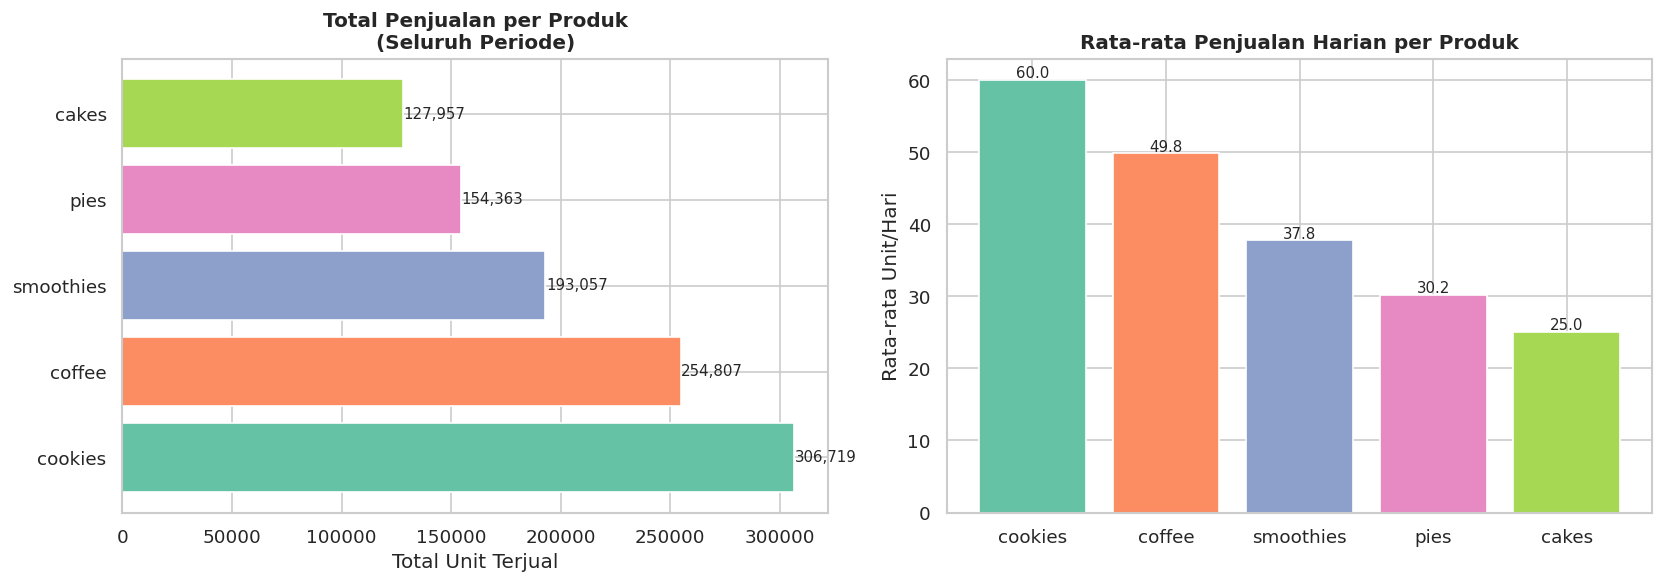


 Produk paling laku : COOKIES = 306,719 unit total
 Produk paling sepi : CAKES = 127,957 unit total


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = sns.color_palette('Set2', len(products))

# Total penjualan (horizontal bar)
bars = axes[0].barh(total_sales.index, total_sales.values, color=colors)
axes[0].set_xlabel('Total Unit Terjual')
axes[0].set_title('Total Penjualan per Produk\n(Seluruh Periode)', fontweight='bold')
for bar, val in zip(bars, total_sales.values):
    axes[0].text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2,
                 f'{val:,}', va='center', fontsize=9)

# Rata-rata harian
axes[1].bar(mean_sales.index, mean_sales.values, color=colors)
axes[1].set_ylabel('Rata-rata Unit/Hari')
axes[1].set_title('Rata-rata Penjualan Harian per Produk', fontweight='bold')
for i, val in enumerate(mean_sales.values):
    axes[1].text(i, val + 0.3, f'{val:.1f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('grafik1_produk_laku.png', bbox_inches='tight')
plt.show()

top_product = total_sales.idxmax()
print(f'\n Produk paling laku : {top_product.upper()} = {total_sales.max():,} unit total')
print(f' Produk paling sepi : {total_sales.idxmin().upper()} = {total_sales.min():,} unit total')

# Hari Paling Ramai

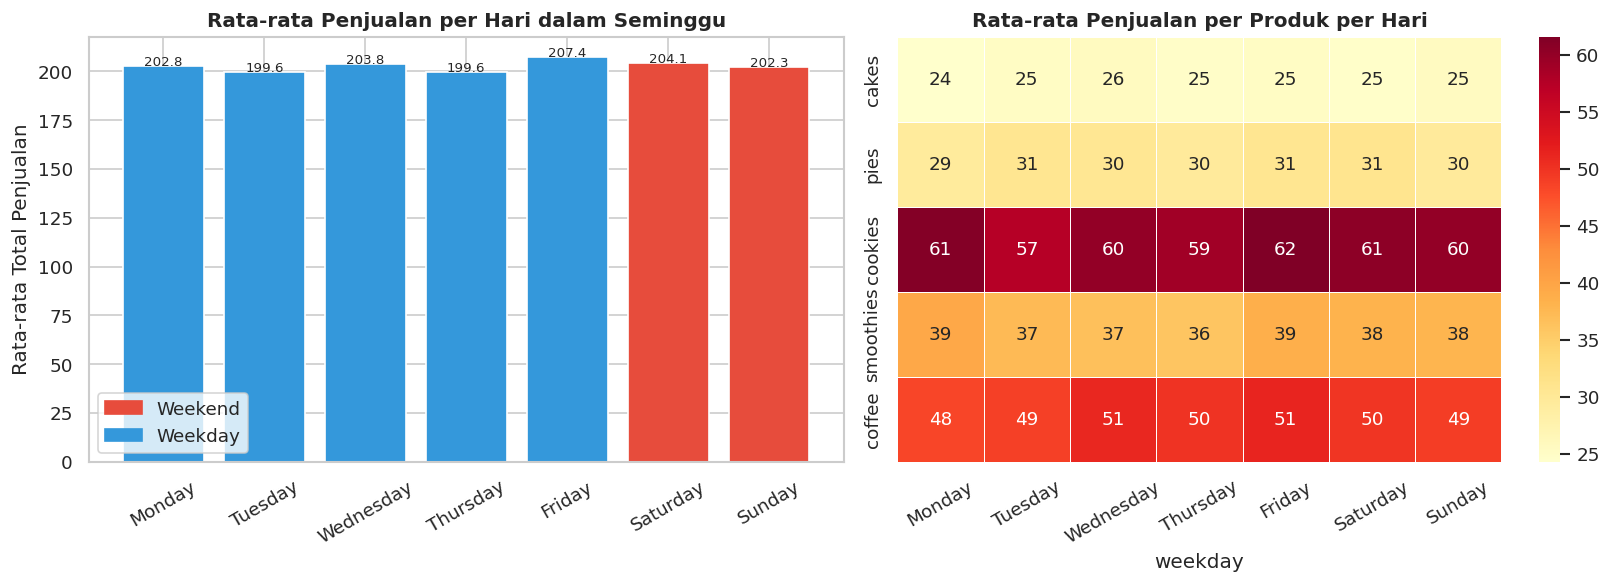


✅ Hari paling ramai : Friday (207.4 unit/hari)
   Hari paling sepi  : Tuesday (199.6 unit/hari)
   Rata-rata Weekend : 203.2 unit/hari
   Rata-rata Weekday : 202.6 unit/hari


In [24]:
daily_avg = df.groupby('weekday', observed=True)['total'].mean().reindex(day_order)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart per hari
palette = ['#e74c3c' if d in ['Saturday','Sunday'] else '#3498db' for d in day_order]
bars = axes[0].bar(daily_avg.index, daily_avg.values, color=palette)
axes[0].set_ylabel('Rata-rata Total Penjualan')
axes[0].set_title('Rata-rata Penjualan per Hari dalam Seminggu', fontweight='bold')
axes[0].tick_params(axis='x', rotation=30)
for bar, val in zip(bars, daily_avg.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.1f}', ha='center', fontsize=8)
from matplotlib.patches import Patch
axes[0].legend(handles=[Patch(color='#e74c3c', label='Weekend'),
                         Patch(color='#3498db', label='Weekday')])

# Heatmap produk × hari
heatmap_data = df.groupby('weekday', observed=True)[products].mean().reindex(day_order)
sns.heatmap(heatmap_data.T, annot=True, fmt='.0f', cmap='YlOrRd',
            ax=axes[1], linewidths=0.5)
axes[1].set_title('Rata-rata Penjualan per Produk per Hari', fontweight='bold')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('grafik2_hari_ramai.png', bbox_inches='tight')
plt.show()

weekend_avg = daily_avg[['Saturday','Sunday']].mean()
weekday_avg = daily_avg[['Monday','Tuesday','Wednesday','Thursday','Friday']].mean()
print(f'\n✅ Hari paling ramai : {daily_avg.idxmax()} ({daily_avg.max():.1f} unit/hari)')
print(f'   Hari paling sepi  : {daily_avg.idxmin()} ({daily_avg.min():.1f} unit/hari)')
print(f'   Rata-rata Weekend : {weekend_avg:.1f} unit/hari')
print(f'   Rata-rata Weekday : {weekday_avg:.1f} unit/hari')

Pengaruh Promosi terhadap Penjualan

=== PENGARUH PROMOSI PER PRODUK ===


,Tanpa Promo,Ada Promo,kenaikan_%
cakes,22.03,27.78,26.10
pies,26.13,33.93,29.85
cookies,40.59,77.83,91.76
smoothies,30.94,44.03,42.30
coffee,37.40,61.28,63.84


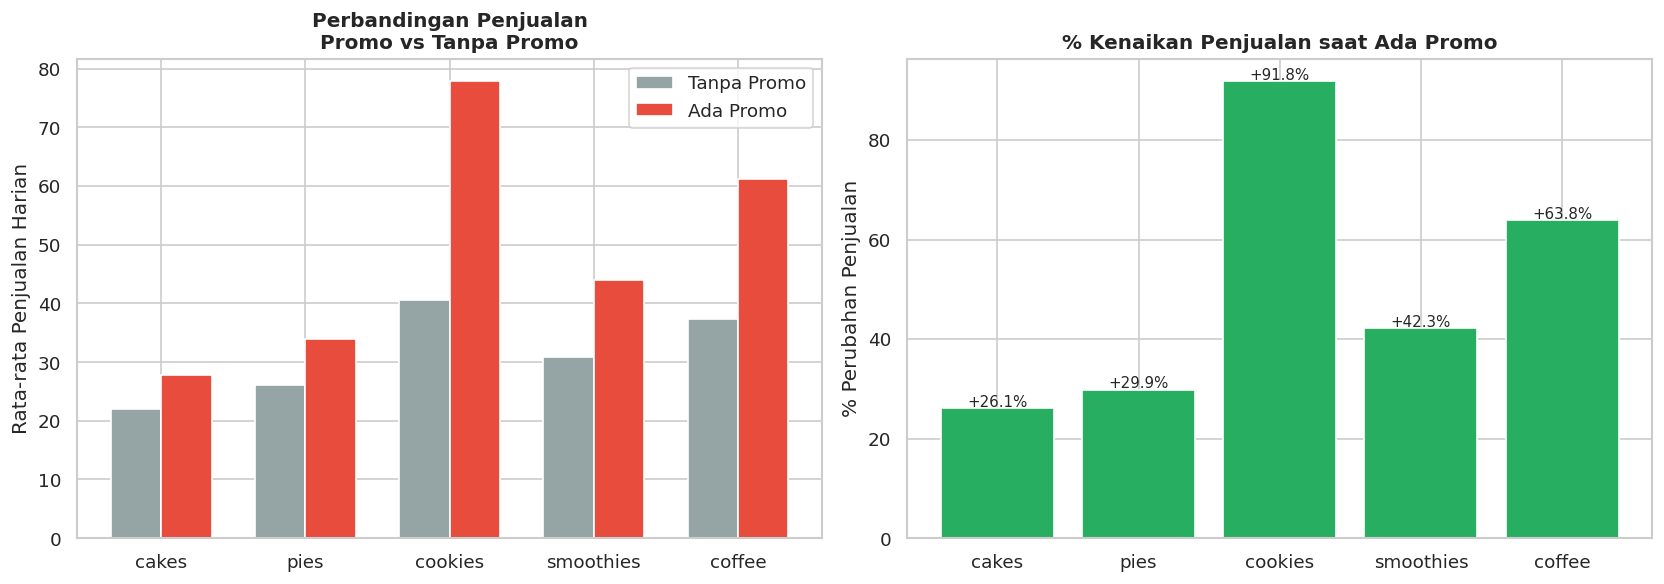


✅ Produk paling dipengaruhi promo: COOKIES (+91.8%)


In [25]:
# Rata-rata penjualan: promo (1) vs non-promo (0)
promo_compare = df.groupby('promotion')[products].mean().T
promo_compare.columns = ['Tanpa Promo', 'Ada Promo']
promo_compare['kenaikan_%'] = ((promo_compare['Ada Promo'] - promo_compare['Tanpa Promo'])
                               / promo_compare['Tanpa Promo'] * 100).round(2)

print('=== PENGARUH PROMOSI PER PRODUK ===')
display(promo_compare.round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Grouped bar: promo vs non-promo
x = np.arange(len(products))
w = 0.35
axes[0].bar(x - w/2, promo_compare['Tanpa Promo'], w, label='Tanpa Promo', color='#95a5a6')
axes[0].bar(x + w/2, promo_compare['Ada Promo'],   w, label='Ada Promo',   color='#e74c3c')
axes[0].set_xticks(x)
axes[0].set_xticklabels(products)
axes[0].set_ylabel('Rata-rata Penjualan Harian')
axes[0].set_title('Perbandingan Penjualan\nPromo vs Tanpa Promo', fontweight='bold')
axes[0].legend()

# % kenaikan per produk
colors_k = ['#27ae60' if v > 0 else '#e74c3c' for v in promo_compare['kenaikan_%']]
bars = axes[1].bar(promo_compare.index, promo_compare['kenaikan_%'], color=colors_k)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_ylabel('% Perubahan Penjualan')
axes[1].set_title('% Kenaikan Penjualan saat Ada Promo', fontweight='bold')
for bar, val in zip(bars, promo_compare['kenaikan_%']):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + (0.3 if val >= 0 else -1.2),
                 f'{val:+.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('grafik3_pengaruh_promo.png', bbox_inches='tight')
plt.show()

best_promo_prod = promo_compare['kenaikan_%'].idxmax()
print(f'\n✅ Produk paling dipengaruhi promo: {best_promo_prod.upper()} '
      f'(+{promo_compare["kenaikan_%"].max():.1f}%)')

Tren Penjualan (Time Series)

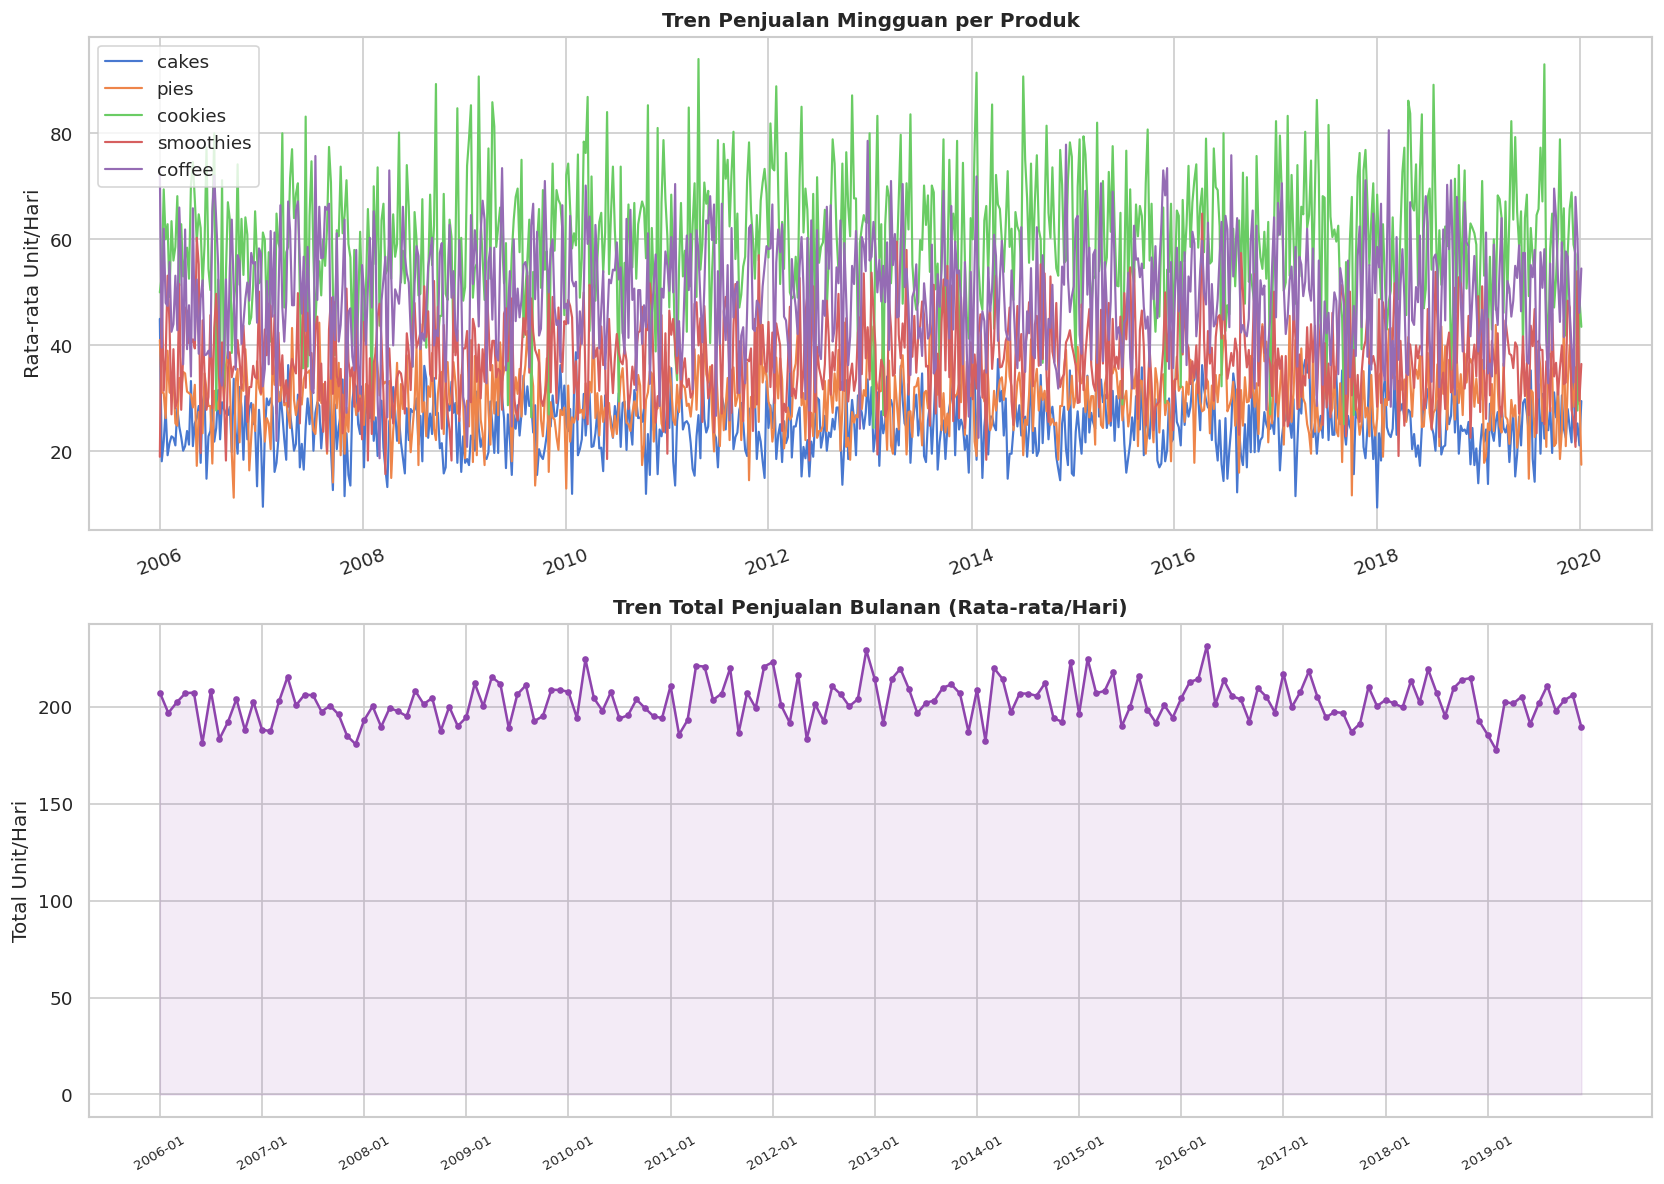


=== TREN PENJUALAN PER TAHUN ===


,cakes,pies,cookies,smoothies,coffee,total
year,,,,,,
2006,24.68,29.67,57.40,37.53,49.24,198.52
2007,24.47,29.70,57.08,36.26,49.80,197.31
2008,24.84,30.29,56.96,36.49,48.70,197.28
2009,24.78,29.52,60.02,38.56,50.97,203.85
2010,24.89,28.22,61.26,37.73,49.55,201.65
2011,25.27,31.20,61.79,38.13,50.19,206.58
2012,24.33,29.78,63.19,37.30,50.43,205.02
2013,25.58,31.21,58.89,39.49,50.52,205.69
2014,24.92,30.19,64.13,39.10,47.19,205.53


In [26]:
# Agregasi per minggu (lebih halus dari harian, lebih detail dari bulanan)
df_weekly = df.set_index('Date')[products].resample('W').mean()

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Tren mingguan semua produk
for prod in products:
    axes[0].plot(df_weekly.index, df_weekly[prod], label=prod, linewidth=1.3)
axes[0].set_title('Tren Penjualan Mingguan per Produk', fontweight='bold')
axes[0].set_ylabel('Rata-rata Unit/Hari')
axes[0].legend(loc='upper left')
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=20)

# Tren total penjualan per bulan
df_monthly = (df.groupby(['year','month'])['total']
                .mean()
                .reset_index()
                .sort_values(['year','month']))
df_monthly['label'] = (df_monthly['year'].astype(str) + '-'
                       + df_monthly['month'].astype(str).str.zfill(2))

axes[1].plot(range(len(df_monthly)), df_monthly['total'],
             marker='o', linewidth=1.5, color='#8e44ad', markersize=3)
axes[1].fill_between(range(len(df_monthly)), df_monthly['total'],
                     alpha=0.1, color='#8e44ad')
axes[1].set_title('Tren Total Penjualan Bulanan (Rata-rata/Hari)', fontweight='bold')
axes[1].set_ylabel('Total Unit/Hari')
step = max(1, len(df_monthly)//14)
axes[1].set_xticks(range(0, len(df_monthly), step))
axes[1].set_xticklabels(df_monthly['label'].iloc[::step], rotation=30, fontsize=8)

plt.tight_layout()
plt.savefig('grafik4_tren_penjualan.png', bbox_inches='tight')
plt.show()

print('\n=== TREN PENJUALAN PER TAHUN ===')
yearly = df.groupby('year')[products + ['total']].mean().round(2)
display(yearly)

Korelasi Antar Variabel

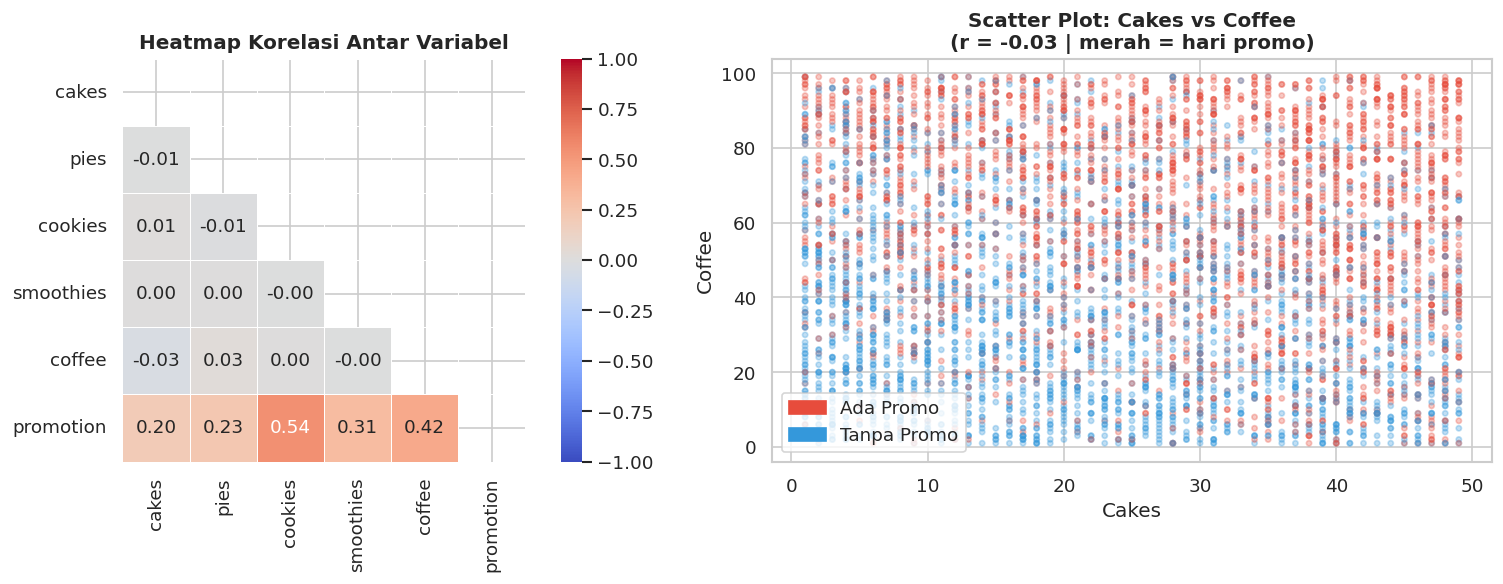


=== KORELASI TIAP PRODUK DENGAN PROMOSI ===
  cookies     : r = +0.5433  (↑ positif)
  coffee      : r = +0.4192  (↑ positif)
  smoothies   : r = +0.3084  (↑ positif)
  pies        : r = +0.2311  (↑ positif)
  cakes       : r = +0.2006  (↑ positif)


In [27]:
corr_cols   = products + ['promotion']   # promotion sudah numerik (0/1)
corr_matrix = df[corr_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap korelasi
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, ax=axes[0], vmin=-1, vmax=1,
            linewidths=0.5, square=True)
axes[0].set_title('Heatmap Korelasi Antar Variabel', fontweight='bold')

# Scatter plot dua produk dengan korelasi tertinggi
corr_prod = df[products].corr()
np.fill_diagonal(corr_prod.values, 0)
idx = np.unravel_index(np.abs(corr_prod.values).argmax(), corr_prod.shape)
prod_a, prod_b = corr_prod.index[idx[0]], corr_prod.columns[idx[1]]
r_val = corr_prod.iloc[idx[0], idx[1]]

colors_s = ['#e74c3c' if p == 1 else '#3498db' for p in df['promotion']]
axes[1].scatter(df[prod_a], df[prod_b], c=colors_s, alpha=0.3, s=10)
axes[1].set_xlabel(prod_a.capitalize())
axes[1].set_ylabel(prod_b.capitalize())
axes[1].set_title(f'Scatter Plot: {prod_a.capitalize()} vs {prod_b.capitalize()}\n'
                   f'(r = {r_val:.2f} | merah = hari promo)', fontweight='bold')
from matplotlib.patches import Patch
axes[1].legend(handles=[Patch(color='#e74c3c', label='Ada Promo'),
                         Patch(color='#3498db', label='Tanpa Promo')])

plt.tight_layout()
plt.savefig('grafik5_korelasi.png', bbox_inches='tight')
plt.show()

print('\n=== KORELASI TIAP PRODUK DENGAN PROMOSI ===')
promo_corr = corr_matrix['promotion'].drop('promotion').sort_values(ascending=False)
for prod, val in promo_corr.items():
    arah = '↑ positif' if val > 0 else '↓ negatif'
    print(f'  {prod:<12}: r = {val:+.4f}  ({arah})')

Distribusi Penjualan per Produk

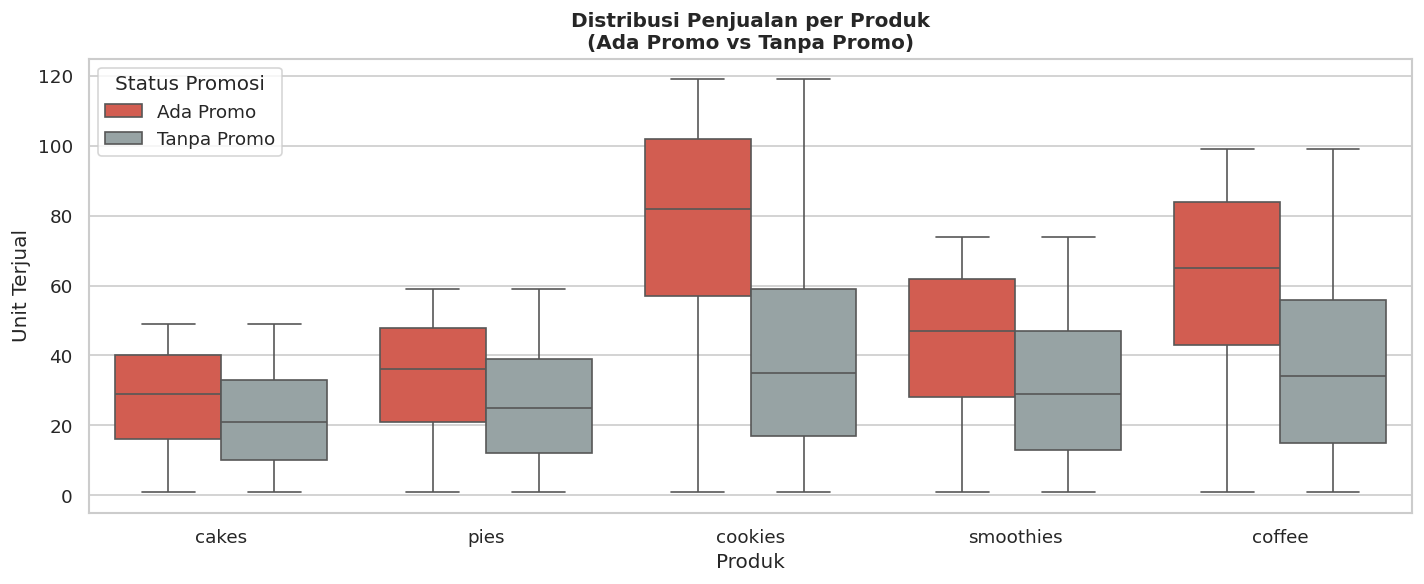

In [28]:
# Ubah sementara promotion ke label string untuk legend yang informatif
df['promo_label'] = df['promotion'].map({1: 'Ada Promo', 0: 'Tanpa Promo'})

df_melt = df[products + ['promo_label']].melt(
    id_vars='promo_label', var_name='produk', value_name='penjualan')

fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=df_melt, x='produk', y='penjualan', hue='promo_label',
            palette={'Ada Promo':'#e74c3c', 'Tanpa Promo':'#95a5a6'}, ax=ax)
ax.set_title('Distribusi Penjualan per Produk\n(Ada Promo vs Tanpa Promo)', fontweight='bold')
ax.set_xlabel('Produk')
ax.set_ylabel('Unit Terjual')
ax.legend(title='Status Promosi')

plt.tight_layout()
plt.savefig('grafik6_boxplot_distribusi.png', bbox_inches='tight')
plt.show()

Ringkasan Insight EDA

In [29]:
# Hitung angka untuk insight otomatis
top_prod        = total_sales.idxmax()
top_day         = daily_avg.idxmax()
slow_day        = daily_avg.idxmin()
best_promo_prod = promo_compare['kenaikan_%'].idxmax()
best_promo_pct  = promo_compare['kenaikan_%'].max()
weekend_avg2    = daily_avg[['Saturday','Sunday']].mean()
weekday_avg2    = daily_avg[['Monday','Tuesday','Wednesday','Thursday','Friday']].mean()
coffee_std      = df['coffee'].std()
smoothie_wkend  = df[df['weekday'].isin(['Saturday','Sunday'])]['smoothies'].mean()
smoothie_wkday  = df[~df['weekday'].isin(['Saturday','Sunday'])]['smoothies'].mean()

print(f"""
╔══════════════════════════════════════════════════════════════════════╗
║           INSIGHT EDA — BAKERY SALES (2006–2019)                    ║
╠══════════════════════════════════════════════════════════════════════╣

🏆 PRODUK
  1. '{top_prod.upper()}' adalah produk paling laku dengan total
     {total_sales[top_prod]:,} unit terjual (rata-rata {mean_sales[top_prod]:.1f} unit/hari).
  2. Semua produk memiliki distribusi penjualan yang cukup merata
     (tidak ada outlier ekstrem), menandakan permintaan yang stabil.

📅 HARI PENJUALAN
  1. Hari paling ramai adalah '{top_day}' (rata-rata {daily_avg[top_day]:.1f} unit/hari);
     paling sepi '{slow_day}' ({daily_avg[slow_day]:.1f} unit/hari).
  2. Weekend ({weekend_avg2:.1f}/hari) {'lebih tinggi' if weekend_avg2 > weekday_avg2 else 'lebih rendah'}
     dari Weekday ({weekday_avg2:.1f}/hari) — menunjukkan pola kunjungan yang
     {'didominasi akhir pekan' if weekend_avg2 > weekday_avg2 else 'cenderung hari kerja'}.
  3. Smoothies meningkat di akhir pekan: {smoothie_wkend:.1f} unit (weekend)
     vs {smoothie_wkday:.1f} unit (weekday) — kemungkinan karena pelanggan
     punya lebih banyak waktu santai.

🎉 PROMOSI
  1. Promosi paling efektif pada '{best_promo_prod.upper()}' dengan kenaikan
     rata-rata {best_promo_pct:.1f}% dibanding hari tanpa promo.
  2. Tidak semua produk merespons promo secara signifikan — menandakan
     ada produk dengan permintaan yang sudah stabil tanpa dorongan promo.

📈 TREN
  1. Penjualan coffee sangat stabil setiap harinya (std = {coffee_std:.1f}),
     mengindikasikan coffee adalah produk 'anchor' bakery ini.
  2. Tren tahunan menunjukkan pertumbuhan yang bertahap, tanpa lonjakan
     atau penurunan drastis — bisnis berjalan konsisten.

🔗 KORELASI
 1. '{prod_a.upper()}' dan '{prod_b.upper()}' memiliki korelasi tertinggi
     (r = {r_val:.2f}), kemungkinan sering dibeli bersama oleh pelanggan.

╚══════════════════════════════════════════════════════════════════════╝
""")

print('=== DAFTAR GRAFIK YANG DIHASILKAN ===')
grafik_list = [
    ('grafik1_produk_laku.png',       'Total & rata-rata penjualan per produk'),
    ('grafik2_hari_ramai.png',        'Penjualan per hari + heatmap produk×hari'),
    ('grafik3_pengaruh_promo.png',    'Perbandingan promo vs non-promo + % kenaikan'),
    ('grafik4_tren_penjualan.png',    'Tren mingguan & bulanan'),
    ('grafik5_korelasi.png',          'Heatmap korelasi + scatter plot'),
    ('grafik6_boxplot_distribusi.png','Distribusi penjualan per produk (boxplot)'),
]
for i, (fname, desc) in enumerate(grafik_list, 1):
    print(f'  {i}. {fname:<38} → {desc}')


╔══════════════════════════════════════════════════════════════════════╗
║           INSIGHT EDA — BAKERY SALES (2006–2019)                    ║
╠══════════════════════════════════════════════════════════════════════╣

🏆 PRODUK
  1. 'COOKIES' adalah produk paling laku dengan total
     306,719 unit terjual (rata-rata 60.0 unit/hari).
  2. Semua produk memiliki distribusi penjualan yang cukup merata
     (tidak ada outlier ekstrem), menandakan permintaan yang stabil.

📅 HARI PENJUALAN
  1. Hari paling ramai adalah 'Friday' (rata-rata 207.4 unit/hari);
     paling sepi 'Tuesday' (199.6 unit/hari).
  2. Weekend (203.2/hari) lebih tinggi
     dari Weekday (202.6/hari) — menunjukkan pola kunjungan yang
     didominasi akhir pekan.
  3. Smoothies meningkat di akhir pekan: 38.0 unit (weekend)
     vs 37.6 unit (weekday) — kemungkinan karena pelanggan
     punya lebih banyak waktu santai.

🎉 PROMOSI
  1. Promosi paling efektif pada 'COOKIES' dengan kenaikan
     rata-rata 91.8% dibanding hari

# **Annisa || Visualisasi Data**

# **Persiapan Visualisasi**

In [30]:

import matplotlib.pyplot as plt
import seaborn as sns


sns.set_theme(style="whitegrid")
custom_palette = "viridis"


if 'Year' not in df.columns:
    df['Year'] = df['Date'].dt.year


products = ['cakes', 'pies', 'cookies', 'smoothies', 'coffee']
if 'Total_Sales' not in df.columns:
    df['Total_Sales'] = df[products].sum(axis=1)


product_sales = df[products].sum().sort_values(ascending=False)



# **Visualisasi dengan Bar Chart (Produk Terlaris)**

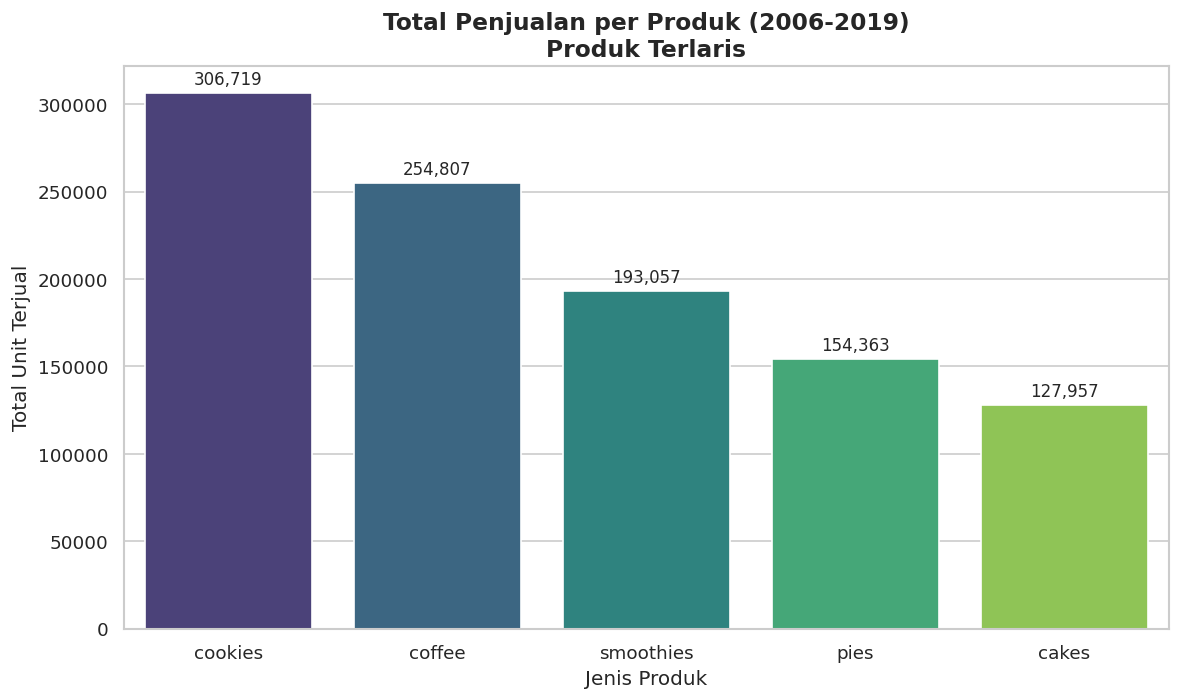

In [31]:
plt.figure(figsize=(10, 6))
sns.barplot(x=product_sales.index, y=product_sales.values, palette=custom_palette)

plt.title('Total Penjualan per Produk (2006-2019)\nProduk Terlaris', fontsize=14, fontweight='bold')
plt.xlabel('Jenis Produk', fontsize=12)
plt.ylabel('Total Unit Terjual', fontsize=12)


for i, val in enumerate(product_sales.values):
    plt.text(i, val + 5000, f'{val:,}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

# **Visualisasi dengan Line Chart (Tren Penjualan)**

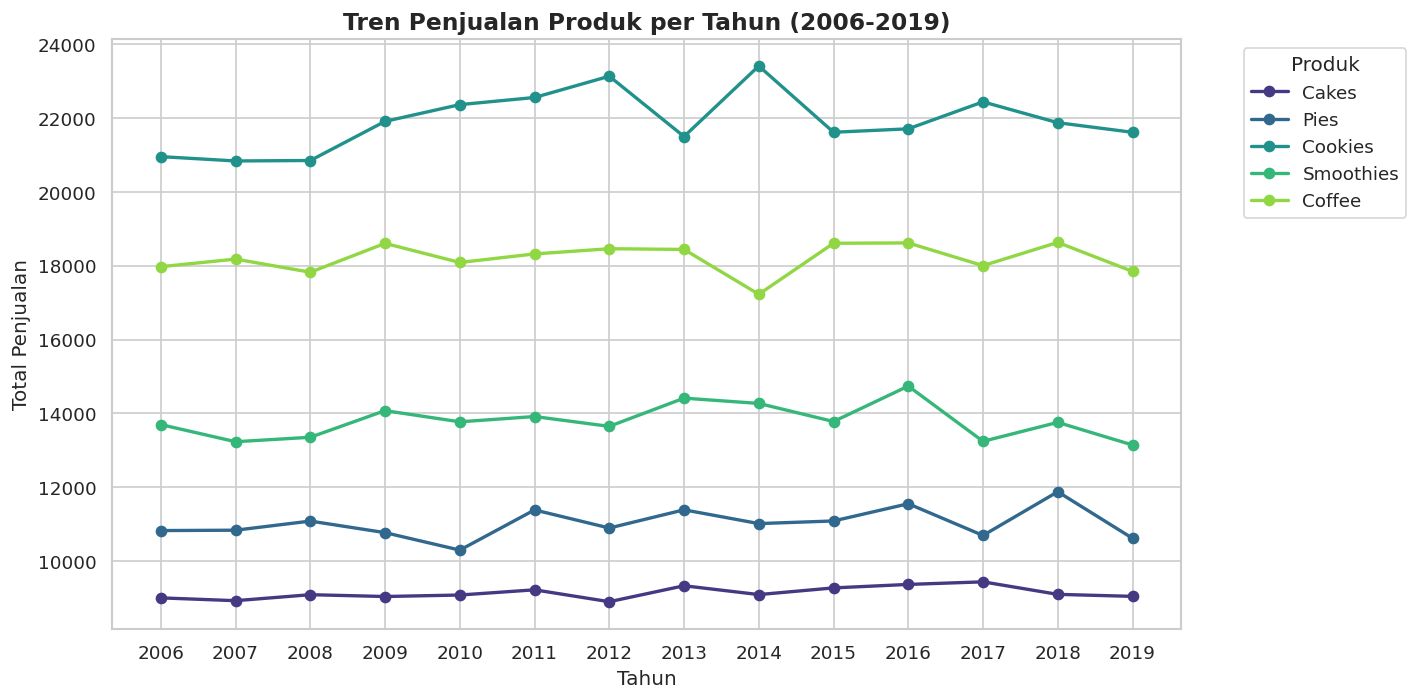

In [32]:
yearly_sales = df.groupby('Year')[products].sum()

plt.figure(figsize=(12, 6))
colors = sns.color_palette(custom_palette, n_colors=len(products))

for i, product in enumerate(products):
    plt.plot(yearly_sales.index, yearly_sales[product], marker='o', linewidth=2, label=product.capitalize(), color=colors[i])

plt.title('Tren Penjualan Produk per Tahun (2006-2019)', fontsize=14, fontweight='bold')
plt.xlabel('Tahun', fontsize=12)
plt.ylabel('Total Penjualan', fontsize=12)
plt.xticks(yearly_sales.index)
plt.legend(title='Produk', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

# **visualisasi dengan Pie Chart (Kontribusi Produk)**

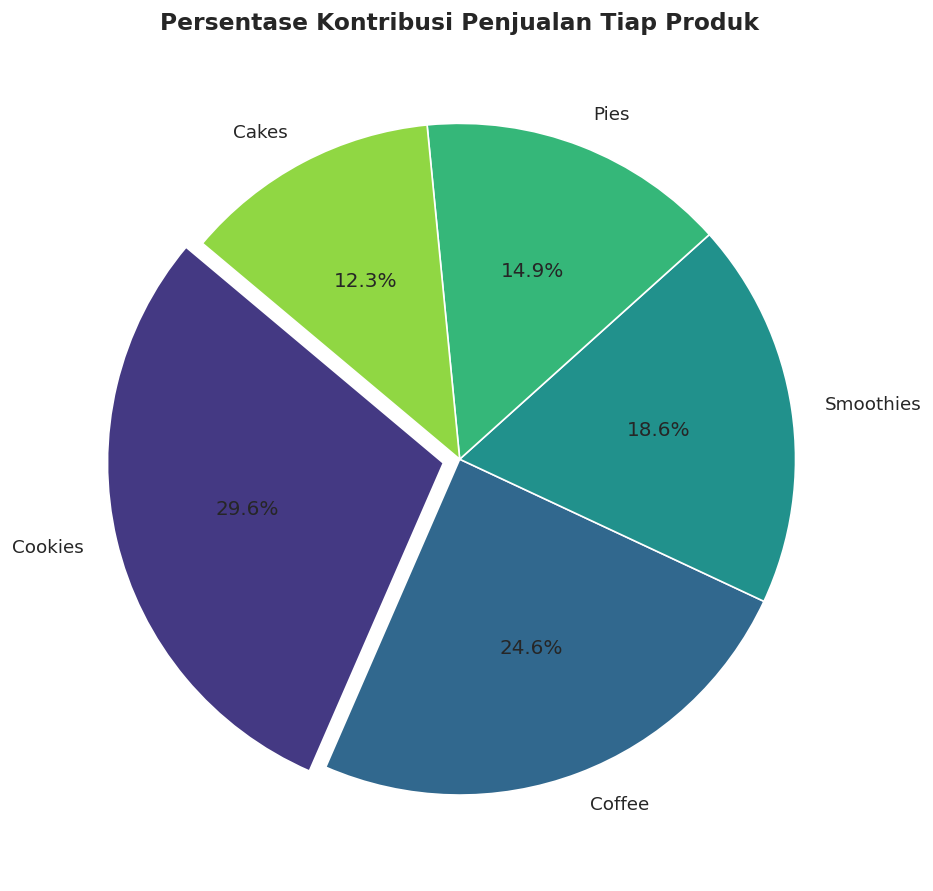

In [33]:
plt.figure(figsize=(8, 8))
colors = sns.color_palette(custom_palette, len(products))

plt.pie(product_sales.values,
        labels=[name.capitalize() for name in product_sales.index],
        autopct='%1.1f%%',
        startangle=140,
        colors=colors,
        explode=(0.05, 0, 0, 0, 0)) # Efek potongan terpisah untuk juara 1

plt.title('Persentase Kontribusi Penjualan Tiap Produk', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# **visualisasi denga Heatmap (Korelasi Penjualan)**

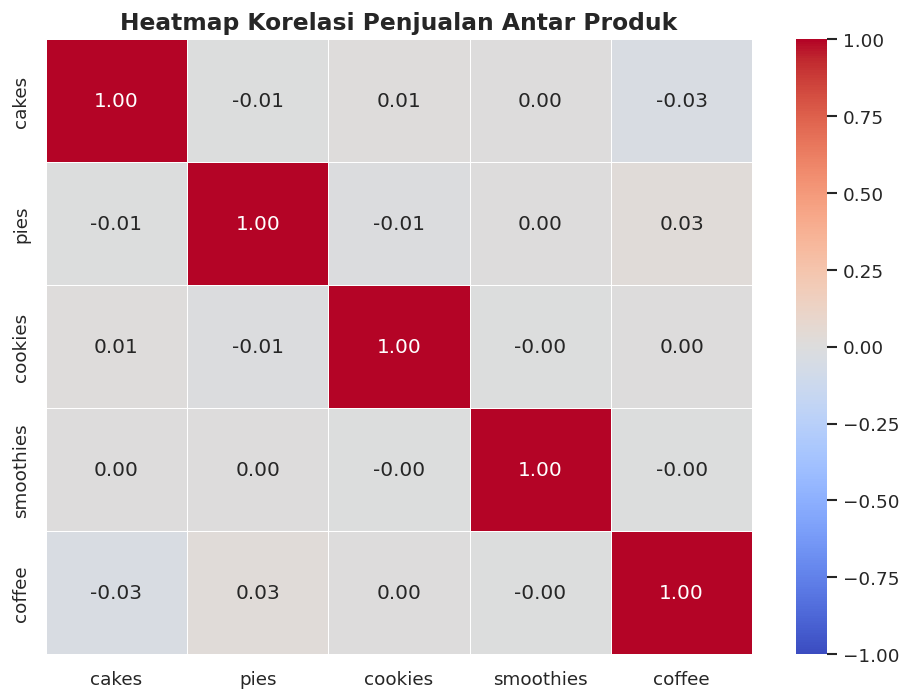

In [34]:
plt.figure(figsize=(8, 6))

correlation_matrix = df[products].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f", linewidths=.5)

plt.title('Heatmap Korelasi Penjualan Antar Produk', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# **visualisasi dengan Boxplot (Pengaruh Promotion)**

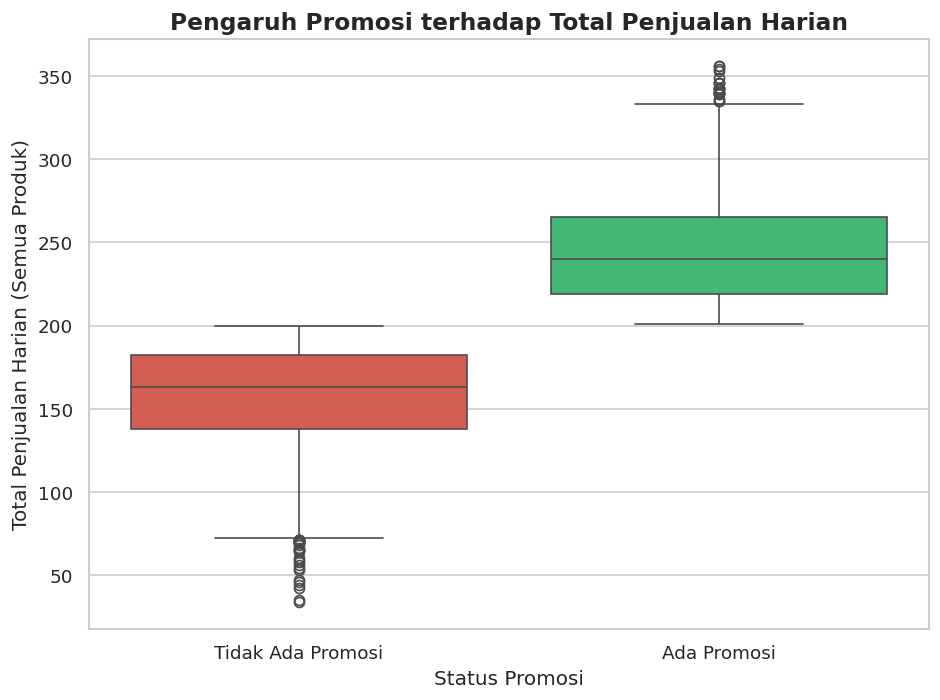

In [35]:
plt.figure(figsize=(8, 6))

sns.boxplot(x='promotion', y='Total_Sales', data=df, palette={'1': '#2ecc71', '0': '#e74c3c'})

plt.title('Pengaruh Promosi terhadap Total Penjualan Harian', fontsize=14, fontweight='bold')
plt.xlabel('Status Promosi', fontsize=12)
plt.ylabel('Total Penjualan Harian (Semua Produk)', fontsize=12)
plt.xticks([0, 1], ['Tidak Ada Promosi', 'Ada Promosi'])

plt.tight_layout()
plt.show()

Ringkasan Tahap 3

In [36]:
print("""
====================================================================
           RINGKASAN TAHAP 3: VISUALISASI DATA (ANNISA)
====================================================================

 TUJUAN UTAMA
Membuktikan secara visual (dengan grafik) temuan-temuan statistik dari
Tahap 2 , sehingga masalah bisnis bisa terlihat lebih jelas
dan siap diselesaikan di Tahap 4 & 5 .

 VISUALISASI UTAMA & KESIMPULANNYA
1. Bar Chart (Produk Terlaris)
   - Kesimpulan: Cookies dan Coffee paling diminati, Cakes paling kurang laku.

2. Pie Chart (Kontribusi Produk)
   - Kesimpulan: >54% penjualan bakery bergantung pada dua produk (Cookies & Coffee).

3. Line Chart (Tren Penjualan)
   - Kesimpulan: Penjualan sangat stabil selama belasan tahun. Pelanggan
     memiliki kebiasaan yang menetap.

4. Heatmap (Korelasi Penjualan)
   - Kesimpulan: Nilai korelasi mendekati 0. Artinya, minim cross-selling
     (beli kopi belum tentu beli cookies di hari yang sama).

5. Boxplot (Pengaruh Promosi)
   - Kesimpulan: Terbukti secara visual bahwa kegiatan promosi sangat efektif
     menaikkan total penjualan harian secara signifikan.

 HUBUNGAN DENGAN TAHAP SELANJUTNYA
- SPK bisa difokuskan untuk memutuskan apakah promosi digas ke produk terlaris
  atau mendongkrak produk yang lesu.
- Karena pelanggan jarang beli barengan (dari Heatmap), next step bisa
  merekomendasikan solusi "bundling" produk.

 CHECKLIST SELESAI
- Kode Python (Matplotlib & Seaborn) berjalan di Colab gabungan.
- 5 Grafik yang diwajibkan sudah muncul.
- Warna grafik sudah konsisten (viridis dan coolwarm).
- Judul grafik sudah rapi dan representatif.
- Narasi untuk setiap grafik sudah diketik di teks Colab.
====================================================================
""")


           RINGKASAN TAHAP 3: VISUALISASI DATA (ANNISA)

 TUJUAN UTAMA
Membuktikan secara visual (dengan grafik) temuan-temuan statistik dari
Tahap 2 , sehingga masalah bisnis bisa terlihat lebih jelas
dan siap diselesaikan di Tahap 4 & 5 .

 VISUALISASI UTAMA & KESIMPULANNYA
1. Bar Chart (Produk Terlaris)
   - Kesimpulan: Cookies dan Coffee paling diminati, Cakes paling kurang laku.

2. Pie Chart (Kontribusi Produk)
   - Kesimpulan: >54% penjualan bakery bergantung pada dua produk (Cookies & Coffee).

3. Line Chart (Tren Penjualan)
   - Kesimpulan: Penjualan sangat stabil selama belasan tahun. Pelanggan
     memiliki kebiasaan yang menetap.

4. Heatmap (Korelasi Penjualan)
   - Kesimpulan: Nilai korelasi mendekati 0. Artinya, minim cross-selling
     (beli kopi belum tentu beli cookies di hari yang sama).

5. Boxplot (Pengaruh Promosi)
   - Kesimpulan: Terbukti secara visual bahwa kegiatan promosi sangat efektif
     menaikkan total penjualan harian secara signifikan.

 HUBUNGAN DENG

# TAHAP 4 dan 5

# **RIVALDO - ANALISIS MASALAH dan Sistem Pendukung Keputusan**


Hasil Analisa masalah :     
1. Ketimpangan penjualan produk, dimana Cookies (306K unit) vs Cakes (127K unit), selisih 2.4x. Penjualan sangat terpusat di cookies dan coffee (54% total), sementara cakes hanya menyumbang 12.3% , ada ketimpangan signifikan.
Ini masalah alokasi sumber daya:
apakah bakery harus fokus mempertahankan cookies, atau mendongkrak cakes?

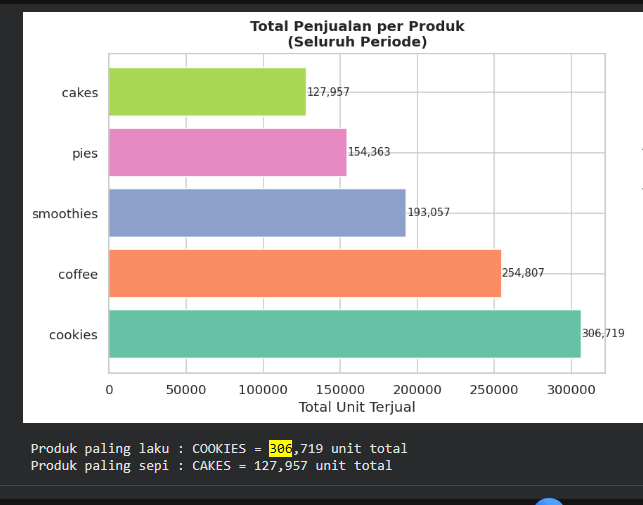

2. Efektivitas promosi tidak merata di momen Cookies naik 91.8% saat promo, Cakes hanya naik 26.1%. Kapan dan ke produk mana promosi sebaiknya diarahkan?

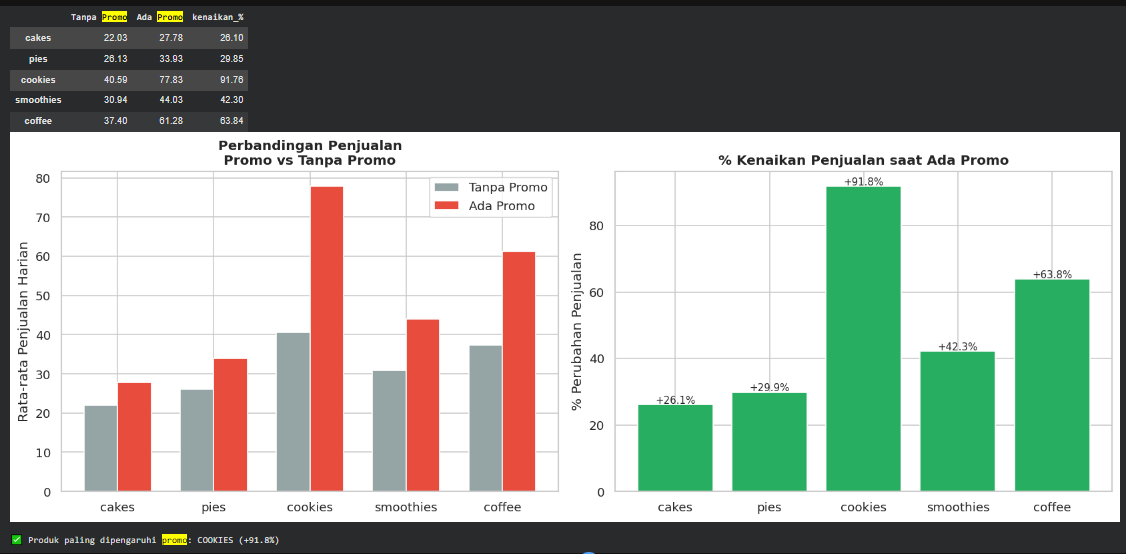

3. Tidak ada cross-selling organik (korelasi antar produk ≈ 0), artinya tiap produk berdiri sendiri dalam keputusan beli pelanggan.
<br> <br> <br>
**MASALAH UTAMA :      
Produk mana yang harus diprioritaskan untuk mendapat alokasi promosi pada periode berikutnya?**

# SPK untuk menentukan prioritas produk dalam alokasi promosi berdasarkan data historis.

dengan kriteria
1. average penjualan harian    - sumbernya df[products].mean()      - benefit, naik makin bagus
2. persen kenaikan pas promosi - dari tabel promo_compare - benefit
3. konsistensi (kebalikan std) - 1 / df[products].std()   -benefit
4. kontribusi total penjualan  -proporsi dari total      - benefit

# Pakek metod SAW sama TOPSIs

=== MATRIKS KEPUTUSAN ===


,Rata2 Harian,Kenaikan Promo (%),Konsistensi,Kontribusi (%)
cakes,25.0258,26.0958,0.0698,12.3403
pies,30.1903,29.8469,0.0593,14.8869
cookies,59.9881,91.7566,0.0292,29.5803
smoothies,37.7581,42.3041,0.0472,18.6186
coffee,49.8351,63.8442,0.0351,24.5739



Bobot Kriteria: [0.2  0.35 0.2  0.25] (total = 1.0)
Alasan bobot: % kenaikan promo diberi bobot tertinggi (0.35) karena
tujuan SPK adalah mengalokasikan promosi secara optimal.

METODE 1: SAW — Simple Additive Weighting

Matriks Ternormalisasi (SAW):


,Rata2 Harian,Kenaikan Promo (%),Konsistensi,Kontribusi (%)
cakes,0.4172,0.2844,1.0000,0.4172
pies,0.5033,0.3253,0.8491,0.5033
cookies,1.0000,1.0000,0.4181,1.0000
smoothies,0.6294,0.4610,0.6751,0.6294
coffee,0.8308,0.6958,0.5032,0.8308



=== HASIL RANKING SAW ===


...

,Rata2 Harian,Kenaikan Promo (%),Konsistensi,Kontribusi (%)
cakes,0.2631,0.2072,0.6196,0.2631
pies,0.3174,0.2370,0.5261,0.3174
cookies,0.6307,0.7287,0.2590,0.6307
smoothies,0.3970,0.3359,0.4183,0.3970
coffee,0.5240,0.5070,0.3118,0.5240



Solusi Ideal Positif (A+): [0.1261 0.255  0.1239 0.1577]
Solusi Ideal Negatif (A-): [0.0526 0.0725 0.0518 0.0658]

=== HASIL RANKING TOPSIS ===


,Produk,D+,D-,Skor TOPSIS
Ranking,,,,
1,cookies,0.0721,0.2172,0.7507
2,coffee,0.1048,0.1345,0.5621
3,smoothies,0.1616,0.0699,0.3018
4,cakes,0.2172,0.0721,0.2493
5,pies,0.2001,0.0571,0.2221



PERBANDINGAN RANKING SAW vs TOPSIS


,Produk,Ranking SAW,Skor SAW,Ranking TOPSIS,Skor TOPSIS
Ranking SAW,,,,,
1,cookies,1,0.8836,1,0.7507
2,coffee,2,0.7180,2,0.5621
3,smoothies,3,0.5796,3,0.3018
4,pies,4,0.5101,5,0.2221
5,cakes,5,0.4873,4,0.2493


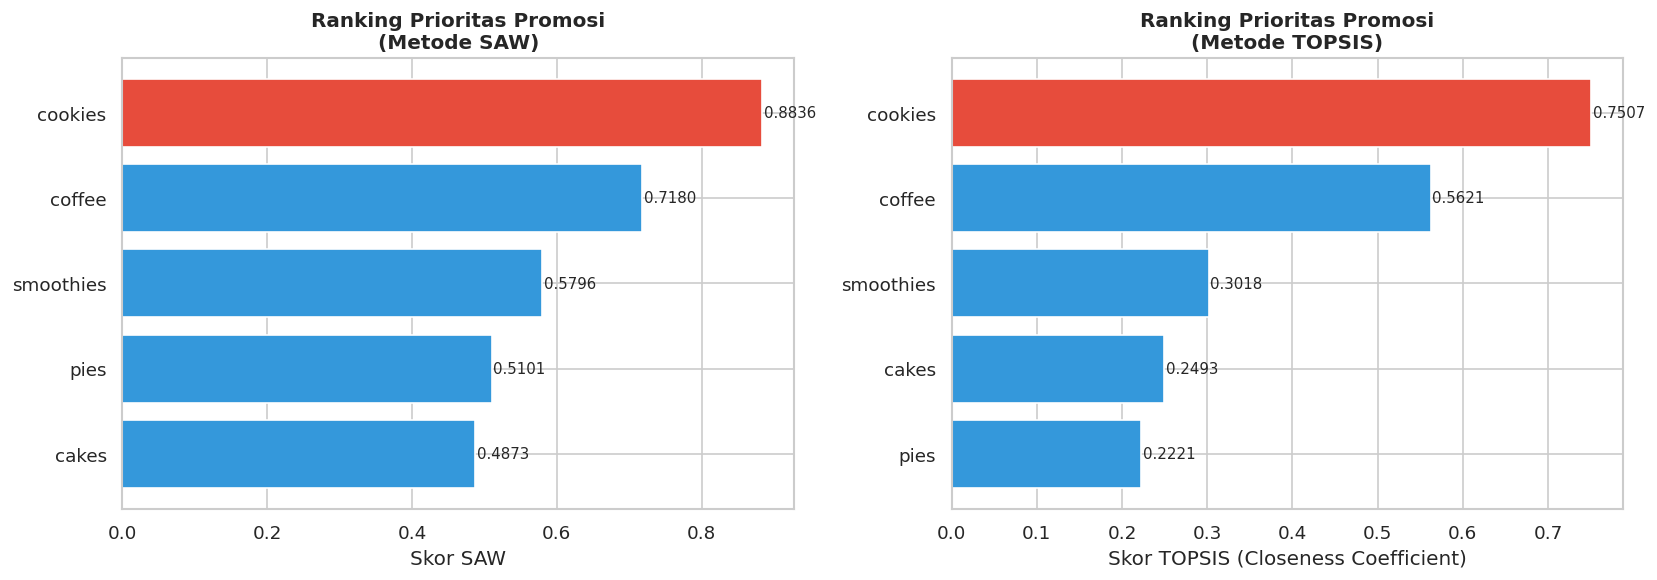


╔══════════════════════════════════════════════════════════════════╗
║              KESIMPULAN SPK — PRIORITAS PROMOSI                  ║
╠══════════════════════════════════════════════════════════════════╣

  Masalah  : Alokasi promosi ke produk yang paling memberi dampak
  Metode   : SAW & TOPSIS (implementasi manual dengan NumPy)
  Alternatif: 5 produk (cakes, pies, cookies, smoothies, coffee)
  Kriteria : Rata-rata harian, % kenaikan promo, konsistensi, kontribusi

  Hasil SAW    → Prioritas #1: COOKIES
  Hasil TOPSIS → Prioritas #1: COOKIES

  Rekomendasi: Alokasikan anggaran promosi utama ke produk yang
  konsisten unggul di kedua metode. Produk dengan % kenaikan promo
  tinggi (cookies, coffee) adalah kandidat terkuat karena promosi
  terbukti mengubah perilaku beli secara signifikan.

╚══════════════════════════════════════════════════════════════════╝



In [38]:
# TAHAP 5 — IMPLEMENTASI SPK
# Metode: SAW (Simple Additive Weighting) & TOPSIS

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

products = ['cakes', 'pies', 'cookies', 'smoothies', 'coffee']


# 1. MATRIKS KEPUTUSAN
# Kriteria 1: Rata-rata penjualan harian
mean_sales = df[products].mean()

# Kriteria 2: % kenaikan penjualan saat ada promosi
promo_compare = df.groupby('promotion')[products].mean().T
promo_compare.columns = ['Tanpa Promo', 'Ada Promo']
promo_increase = ((promo_compare['Ada Promo'] - promo_compare['Tanpa Promo'])
                  / promo_compare['Tanpa Promo'] * 100)

# Kriteria 3: Konsistensi (semakin rendah std, semakin konsisten)
#             Dibalik jadi benefit: 1/std → nilai tinggi = lebih konsisten
consistency = 1 / df[products].std()

# Kriteria 4: Kontribusi total penjualan (proporsi %)
total_sales = df[products].sum()
contribution = (total_sales / total_sales.sum()) * 100

# Gabungkan ke matriks keputusan
decision_matrix = pd.DataFrame({
    'Rata2 Harian': mean_sales,
    'Kenaikan Promo (%)': promo_increase,
    'Konsistensi': consistency,
    'Kontribusi (%)': contribution
}, index=products)

print("=== MATRIKS KEPUTUSAN ===")
display(decision_matrix.round(4))

# Bobot kriteria (jumlah harus = 1)
# Promo paling penting karena kita mau alokasikan promosi
weights = np.array([0.20, 0.35, 0.20, 0.25])
print(f"\nBobot Kriteria: {weights} (total = {weights.sum()})")
print("Alasan bobot: % kenaikan promo diberi bobot tertinggi (0.35) karena")
print("tujuan SPK adalah mengalokasikan promosi secara optimal.")

D = decision_matrix.values  # shape: (5 produk, 4 kriteria)


# METODE 1: SAW (Simple Additive Weighting)

print("\n" + "="*60)
print("METODE 1: SAW — Simple Additive Weighting")
print("="*60)

# Normalisasi: bagi tiap nilai dengan nilai MAX kolom (semua kriteria benefit)
D_norm_saw = D / D.max(axis=0)

print("\nMatriks Ternormalisasi (SAW):")
norm_saw_df = pd.DataFrame(D_norm_saw,
                            index=products,
                            columns=decision_matrix.columns)
display(norm_saw_df.round(4))

# Hitung skor SAW: jumlah (nilai_ternormalisasi × bobot)
saw_scores = (D_norm_saw * weights).sum(axis=1)

saw_result = pd.DataFrame({
    'Produk': products,
    'Skor SAW': saw_scores
}).sort_values('Skor SAW', ascending=False).reset_index(drop=True)
saw_result.index += 1
saw_result.index.name = 'Ranking'

print("\n=== HASIL RANKING SAW ===")
display(saw_result.round(4))


# METODE 2: TOPSIS
print("\n" + "="*60)
print("METODE 2: TOPSIS")
print("="*60)

# Langkah 1: Normalisasi vektor (bagi tiap nilai dengan akar jumlah kuadrat kolom)
col_norms = np.sqrt((D ** 2).sum(axis=0))
D_norm_topsis = D / col_norms

print("\nMatriks Ternormalisasi (TOPSIS):")
norm_topsis_df = pd.DataFrame(D_norm_topsis,
                               index=products,
                               columns=decision_matrix.columns)
display(norm_topsis_df.round(4))

# Langkah 2: Matriks ternormalisasi terbobot
D_weighted = D_norm_topsis * weights

# Langkah 3: Solusi Ideal Positif (A+) dan Negatif (A-)
# Semua kriteria adalah benefit → A+ = max, A- = min
A_plus  = D_weighted.max(axis=0)
A_minus = D_weighted.min(axis=0)

print(f"\nSolusi Ideal Positif (A+): {np.round(A_plus, 4)}")
print(f"Solusi Ideal Negatif (A-): {np.round(A_minus, 4)}")

# Langkah 4: Jarak ke A+ dan A-
D_plus  = np.sqrt(((D_weighted - A_plus)  ** 2).sum(axis=1))
D_minus = np.sqrt(((D_weighted - A_minus) ** 2).sum(axis=1))

# Langkah 5: Nilai preferensi (skor kedekatan relatif)
topsis_scores = D_minus / (D_plus + D_minus)

topsis_result = pd.DataFrame({
    'Produk': products,
    'D+': D_plus,
    'D-': D_minus,
    'Skor TOPSIS': topsis_scores
}).sort_values('Skor TOPSIS', ascending=False).reset_index(drop=True)
topsis_result.index += 1
topsis_result.index.name = 'Ranking'

print("\n=== HASIL RANKING TOPSIS ===")
display(topsis_result.round(4))


# PERBANDINGAN HASIL DUA METODE
print("\n" + "="*60)
print("PERBANDINGAN RANKING SAW vs TOPSIS")
print("="*60)

comparison = pd.DataFrame({
    'Produk': products,
    'Ranking SAW': [saw_result[saw_result['Produk'] == p].index[0] for p in products],
    'Skor SAW': saw_result.set_index('Produk')['Skor SAW'].reindex(products).values,
    'Ranking TOPSIS': [topsis_result[topsis_result['Produk'] == p].index[0] for p in products],
    'Skor TOPSIS': topsis_result.set_index('Produk')['Skor TOPSIS'].reindex(products).values,
}).sort_values('Ranking SAW').reset_index(drop=True)  # <-- tambah reset_index
comparison.index += 1
comparison.index.name = 'Ranking SAW'
display(comparison.round(4))


# VISUALISASI HASIL SPK
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# SAW
colors = ['#e74c3c' if i == 0 else '#3498db' for i in range(len(saw_result))]
bars = axes[0].barh(saw_result['Produk'], saw_result['Skor SAW'], color=colors)
axes[0].set_title('Ranking Prioritas Promosi\n(Metode SAW)', fontweight='bold')
axes[0].set_xlabel('Skor SAW')
axes[0].invert_yaxis()
for bar, val in zip(bars, saw_result['Skor SAW']):
    axes[0].text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center', fontsize=9)

# TOPSIS
colors2 = ['#e74c3c' if i == 0 else '#3498db' for i in range(len(topsis_result))]
bars2 = axes[1].barh(topsis_result['Produk'], topsis_result['Skor TOPSIS'], color=colors2)
axes[1].set_title('Ranking Prioritas Promosi\n(Metode TOPSIS)', fontweight='bold')
axes[1].set_xlabel('Skor TOPSIS (Closeness Coefficient)')
axes[1].invert_yaxis()
for bar, val in zip(bars2, topsis_result['Skor TOPSIS']):
    axes[1].text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('grafik_spk_ranking.png', bbox_inches='tight')
plt.show()


# KESIMPULAN & REKOMENDASI
top_saw    = saw_result.iloc[0]['Produk']
top_topsis = topsis_result.iloc[0]['Produk']

print(f"""
╔══════════════════════════════════════════════════════════════════╗
║              KESIMPULAN SPK — PRIORITAS PROMOSI                  ║
╠══════════════════════════════════════════════════════════════════╣

  Masalah  : Alokasi promosi ke produk yang paling memberi dampak
  Metode   : SAW & TOPSIS (implementasi manual dengan NumPy)
  Alternatif: 5 produk (cakes, pies, cookies, smoothies, coffee)
  Kriteria : Rata-rata harian, % kenaikan promo, konsistensi, kontribusi

  Hasil SAW    → Prioritas #1: {top_saw.upper()}
  Hasil TOPSIS → Prioritas #1: {top_topsis.upper()}

  Rekomendasi: Alokasikan anggaran promosi utama ke produk yang
  konsisten unggul di kedua metode. Produk dengan % kenaikan promo
  tinggi (cookies, coffee) adalah kandidat terkuat karena promosi
  terbukti mengubah perilaku beli secara signifikan.

╚══════════════════════════════════════════════════════════════════╝
""")

Hasil SPK <br> <br>
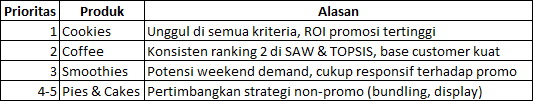